<a href="https://colab.research.google.com/github/amina-safrin/DataScience_Lab/blob/main/program9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Data Loading

In [4]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
df_cancer = pd.DataFrame(data.data, columns=data.feature_names)
df_cancer['diagnosis'] = data.target

print("Breast Cancer dataset loaded successfully!")
print("First 5 rows of the dataset:")
print(df_cancer.head())
print("\nDataset info:")
df_cancer.info()

Breast Cancer dataset loaded successfully!
First 5 rows of the dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dime

In [5]:
df_cancer.to_csv('Breast_Cancer.csv', index=False)
print("Dataset saved to 'Breast_Cancer.csv'")

Dataset saved to 'Breast_Cancer.csv'


### 2. Data Preprocessing, Exploratory Data Analysis (EDA) and Model Training

Dataset 'Breast_Cancer.csv' loaded successfully.

--- 1. Basic EDA ---
First five records:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

 

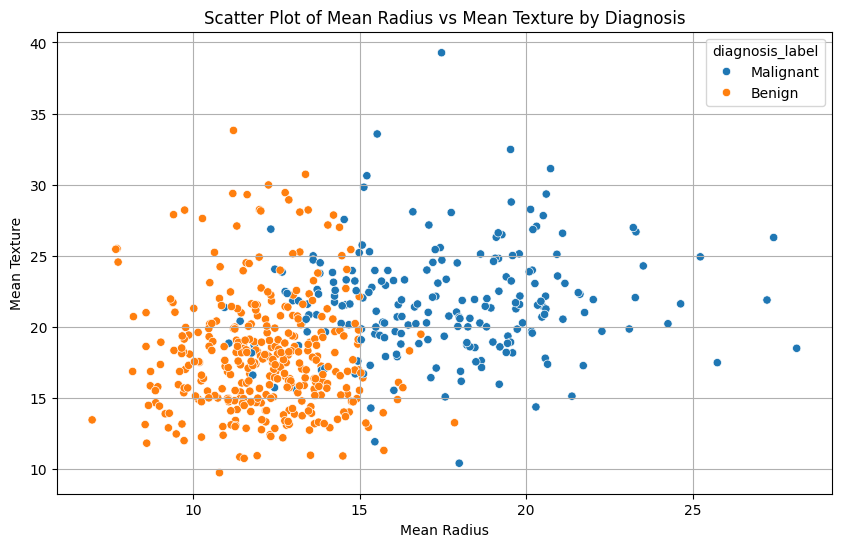

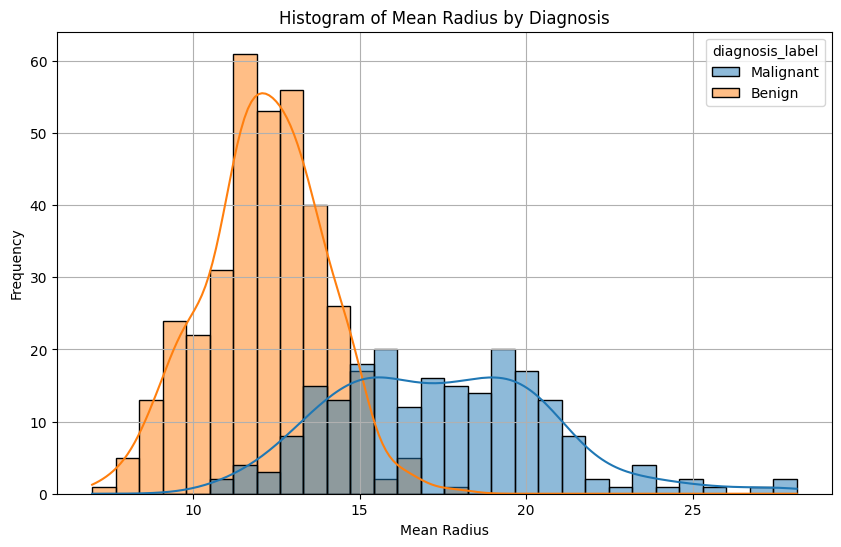

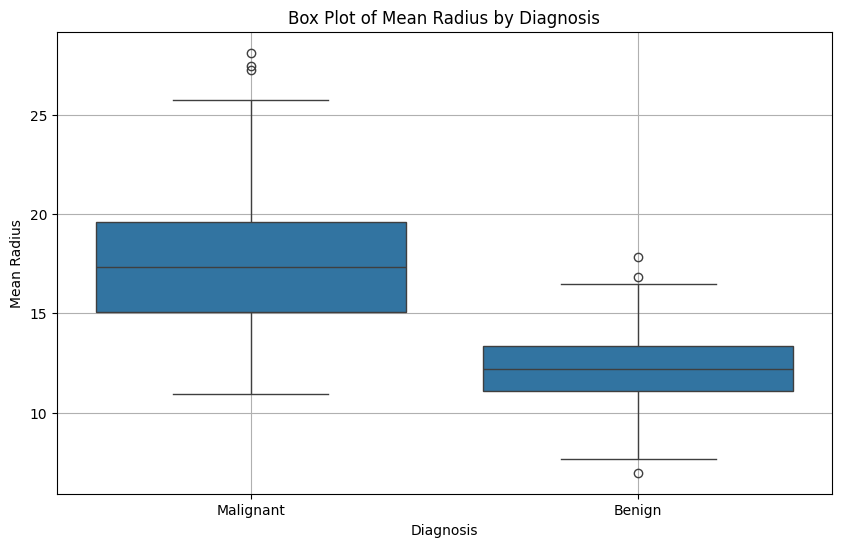

--- 3. Gaussian Naïve Bayes Classification ---
--- 4. Display Classification Report and Accuracy ---
Classification Report:
              precision    recall  f1-score   support

   Malignant       1.00      0.93      0.96        43
      Benign       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Accuracy: 0.9737


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

try:
    df = pd.read_csv('Breast_Cancer.csv')
    print("Dataset 'Breast_Cancer.csv' loaded successfully.\n")
except FileNotFoundError:
    print("Error: 'Breast_Cancer.csv' not found. Please ensure it's in the Colab environment.")
    print("Skipping further operations as the dataset is not available.")
    df = None

if df is not None:
    df['diagnosis_label'] = df['diagnosis'].map({0: 'Malignant', 1: 'Benign'})

    print("--- 1. Basic EDA ---")

    print("First five records:")
    print(df.head())
    print("\n")

    print("Missing values per column:")
    print(df.isnull().sum())
    print("\n")

    print("Descriptive statistics:")
    print(df.describe())
    print("\n")

    print("Diagnosis distribution:")
    print(df['diagnosis_label'].value_counts())
    print("\n")

    print("--- 2. Plotting ---")

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='mean radius', y='mean texture', hue='diagnosis_label')
    plt.title('Scatter Plot of Mean Radius vs Mean Texture by Diagnosis')
    plt.xlabel('Mean Radius')
    plt.ylabel('Mean Texture')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='mean radius', kde=True, bins=30, hue='diagnosis_label')
    plt.title('Histogram of Mean Radius by Diagnosis')
    plt.xlabel('Mean Radius')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='diagnosis_label', y='mean radius')
    plt.title('Box Plot of Mean Radius by Diagnosis')
    plt.xlabel('Diagnosis')
    plt.ylabel('Mean Radius')
    plt.grid(True)
    plt.show()

    print("--- 3. Gaussian Naïve Bayes Classification ---")

    X = df.drop(columns=['diagnosis', 'diagnosis_label'], errors='ignore')
    y = df['diagnosis']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    gnb = GaussianNB()
    gnb.fit(X_train, y_train)

    y_pred = gnb.predict(X_test)

    print("--- 4. Display Classification Report and Accuracy ---")

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy: {accuracy:.4f}")
else:
    print("Cannot proceed with EDA, plotting, and model training as dataset was not loaded.")